# Random Forest Classifier

In [23]:
# If using Google colab with a local file
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('E-Commerce Shipping Data.csv')

Saving E-Commerce Shipping Data.csv to E-Commerce Shipping Data (2).csv


In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# If using local files from the GitHUb
#df = pd.read_csv('../assets/Train.csv')

In [25]:
# Main RF parameters
RF_PARAMETERS = dict(

    ccp_alpha         = 0.0,        # Complexity parameter for Minimal Cost-Complexity Pruning
    n_estimators      = 200,        # Number of trees in the forest
    criterion         = 'gini',     # Split quality metric: 'gini' | 'entropy' | 'log_loss'  ###CLASSIFIER###
    max_depth         = 12,       # Max depth per tree (None = grow until pure)
    min_samples_split = 5,          # Min samples required to split a node
    min_samples_leaf  = 1,          # Min samples required at a leaf node
    min_weight_fraction_leaf = 0.0, # Min weighted fraction of total weights at a leaf
    max_features      = 'sqrt',     # Features considered per split: 'sqrt'|'log2'|int|float
    max_leaf_nodes    = None,       # Max number of leaf nodes (None = unlimited)
    min_impurity_decrease = 0.0,    # A split is made only if impurity decreases by this much

    bootstrap         = True,       # Whether to use bootstrap samples
    oob_score         = True,       # Use out-of-bag samples to estimate generalisation
    max_samples       = None,       # Samples per tree if bootstrap=True (None = full dataset)
    class_weight      = 'balanced_subsample',       # None | 'balanced' | 'balanced_subsample' | dict
    n_jobs=-1

)

In [26]:
df.drop(columns=['ID'], inplace=True)

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in ['Customer_care_calls', 'Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    df[col] = df[col].clip(Q1-1.5*(Q3-Q1), Q3+1.5*(Q3-Q1))

df['Gender'] = (df['Gender'] == 'M').astype(int)
df['Product_importance'] = df['Product_importance'].map({'low': 0, 'medium': 1, 'high': 2})
cat_dummies = pd.get_dummies(df[['Warehouse_block', 'Mode_of_Shipment']], drop_first=True).astype(float)

target = 'Reached.on.Time_Y.N'
numeric_features = [
    'Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases',
    'Product_importance', 'Customer_rating', 'Gender',
    'Discount_offered', 'Weight_in_gms',
]

X_full = pd.concat([df[numeric_features], cat_dummies], axis=1)
y_full = df[target]

df_bal = X_full.copy()
df_bal[target] = y_full.values
minority = df_bal[df_bal[target] == 0]
majority = df_bal[df_bal[target] == 1].sample(n=len(minority), random_state=42)
balanced = pd.concat([minority, majority]).sample(frac=1, random_state=42)
X = balanced.drop(columns=[target])
y = balanced[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scale_cols = ['Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases',
              'Discount_offered', 'Weight_in_gms']
scaler = StandardScaler()
X_train = X_train.copy(); X_test = X_test.copy()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

In [27]:
print("Split sizes:")
print(f'Train: {X_train.shape[0]:>5} samples  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test : {X_test.shape[0]:>5} samples  ({X_test.shape[0]/len(X)*100:.1f}%)')

print("\nClass balance:")
print(y_train.value_counts().sort_index())
print(X.shape)
print(X.columns.tolist())

Split sizes:
Train:  7097 samples  (80.0%)
Test :  1775 samples  (20.0%)

Class balance:
Reached.on.Time_Y.N
0    3548
1    3549
Name: count, dtype: int64
(8872, 14)
['Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Customer_rating', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship']


In [28]:
# Training the Random Forest
rf_model = RandomForestClassifier(**RF_PARAMETERS)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=12,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       oob_score=True)

In [29]:
# Training Scores
y_train_pred = rf_model.predict(X_train)

print('Training Set \n------------------------------')
print(f'Accuracy    : {accuracy_score(y_train, y_train_pred):.4f}')
print(f'Recall      : {recall_score(y_train, y_train_pred, average="weighted"):.4f}')
print(f'Precision   : {precision_score(y_train, y_train_pred, average="weighted"):.4f}')
print(f'F1-Score   : {f1_score(y_train, y_train_pred, average="weighted"):.4f}')
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

# Test Scores
y_test_pred = rf_model.predict(X_test)
y_test_prob = rf_model.predict_proba(X_test)[:, 1]

print('Test Set \n------------------------------')
print(f'Accuracy    : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Recall      : {recall_score(y_test, y_test_pred, average="weighted"):.4f}')
print(f'Precision   : {precision_score(y_test, y_test_pred, average="weighted"):.4f}')
print(f'F1-Score   : {f1_score(y_test, y_test_pred, average="weighted"):.4f}')
print(f'ROC-AUC     : {roc_auc_score(y_test, y_test_prob, average="weighted"):.4f}')
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")


Training Set 
------------------------------
Accuracy    : 0.8227
Recall      : 0.8227
Precision   : 0.8675
F1-Score   : 0.8172
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test Set 
------------------------------
Accuracy    : 0.7245
Recall      : 0.7245
Precision   : 0.7937
F1-Score   : 0.7072
ROC-AUC     : 0.7370
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


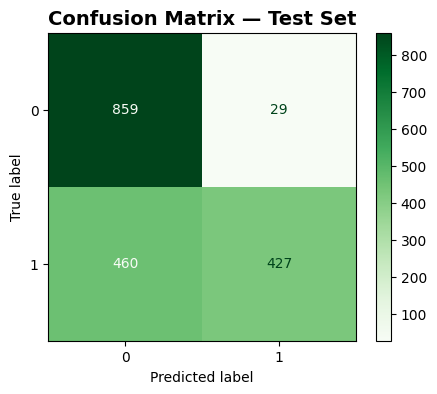

In [30]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.show()

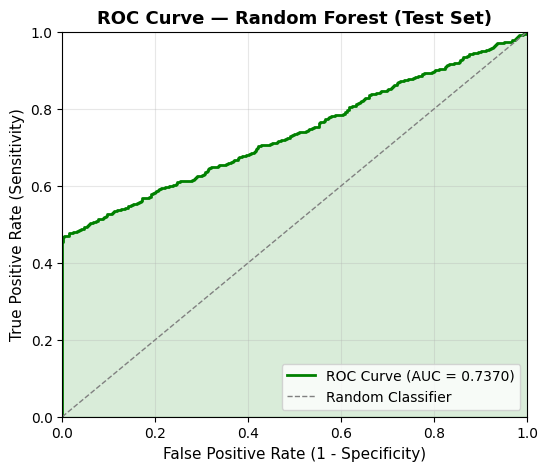

In [31]:
# ROC Curve with AUC

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

fig, axes = plt.subplots(figsize=(6, 5))
axes.plot(fpr, tpr, color='green', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_test_prob):.4f})')
axes.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random Classifier')
axes.fill_between(fpr, tpr, alpha=0.15, color='green')
axes.set_xlim([0.0, 1.0])
axes.set_ylim([0.0, 1.0])
axes.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
axes.set_title('ROC Curve — Random Forest (Test Set)', fontsize=13, fontweight='bold')
axes.legend(loc='lower right', fontsize=10)
axes.grid(alpha=0.3)

plt.show()

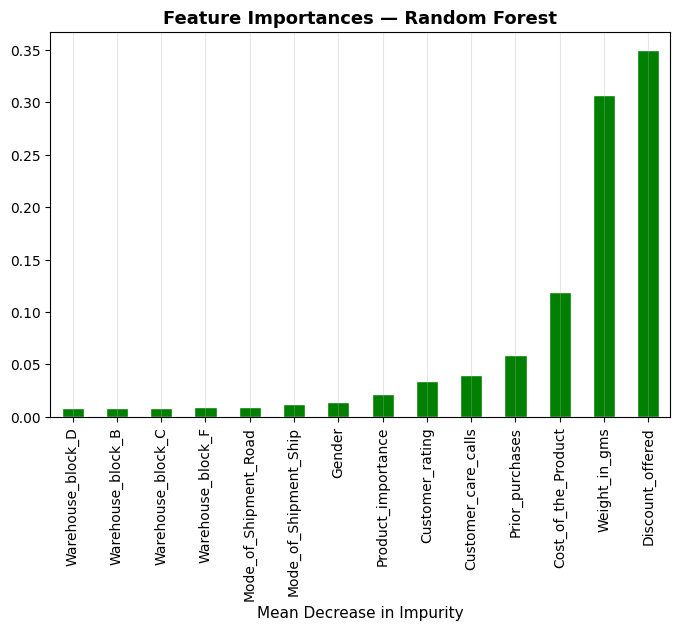

In [32]:
# Feature Importance Measured with Mean Decrease in Impurity

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances_sorted.plot(kind='bar', ax=ax, color='green', edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity', fontsize=11)
ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.show()

In [33]:
########## MIGHT MODIFY ################
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(**RF_PARAMETERS),
    X, y, cv=skf, scoring='accuracy'
)
for i, s in enumerate(cv_scores, 1):
    print(f'Fold {i}: {s:.4f}')
print(f'\nMean : {cv_scores.mean():.4f}')
print(f'Std  : {cv_scores.std():.4f}')

Fold 1: 0.7273
Fold 2: 0.7324
Fold 3: 0.7255
Fold 4: 0.7345
Fold 5: 0.7283

Mean : 0.7296
Std  : 0.0033
